# Get the Required libraries

In [2]:
#basics Libraries 
import numpy as np
import pandas as pd

#Visualization libraries 
import matplotlib.pyplot as plt 
import pydot
import seaborn as sns

#Evaluation libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

## Load the dataset

In [4]:
fashion_train=pd.read_csv("fashion-mnist_train.csv")
fashion_test=pd.read_csv("fashion-mnist_test.csv")

In [10]:
fashion_train.shape
#Train data was in 2D means it already fit for ANN

(60000, 785)

## Input & Output, train & test data split 

In [62]:
#Input Split
x_train_fashion = fashion_train.drop('label',axis=1)
y_train_fashion = fashion_train['label']

#Output Split
x_test_fashion = fashion_test.drop('label',axis=1)
y_test_fashion = fashion_test['label']

In [56]:
x_train_fashion.shape

(60000, 784)

In [67]:
y_train_fashion.shape

(60000,)

In [63]:
y_train_fashion[5]

np.int64(2)

In [60]:
#The data was in 2D so we can't see the data image, for check the dataset we change the dataset 2D to 3D 

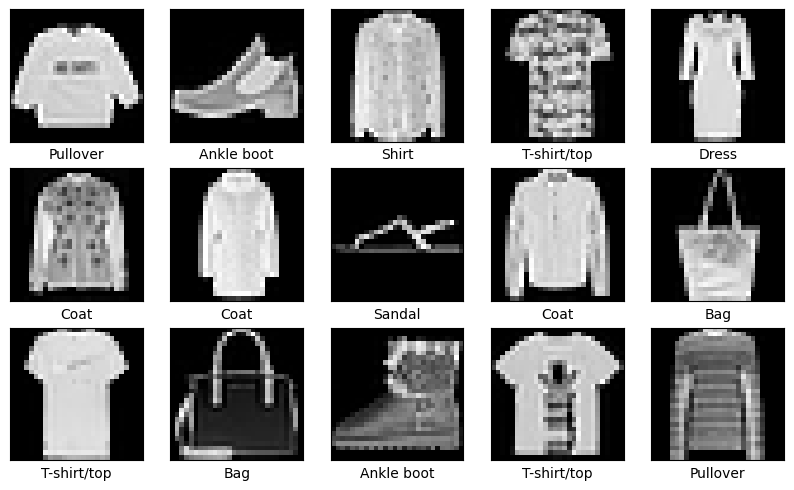

In [61]:
#Reshaping the dataset
x_train_reshape = x_train_fashion.values.reshape(-1,28,28) #28x28=784 #-1 means it mention all the images
x_test_reshape = x_train_fashion.values.reshape(-1,28,28) 

#Names of clothing accessories in order 
col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#Visualizing the images
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_reshape[i], cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])
plt.show()

In [68]:
#Encoding the fashion Labels
y_train_fashion = to_categorical(y_train_fashion, num_classes=10)

y_test_fashion = to_categorical(y_test_fashion, num_classes=10)

In [99]:
y_test_fashion[0]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## Creating the ANN brain

In [71]:
#Creating base neural network
model = keras.Sequential([
    #Input layer
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    
    #Hidden layer 1
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    
    #Hidden layer 2
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),
    
    #Output layer
    layers.BatchNormalization(),
    layers.Dense(10,activation='softmax'),
])

#Compiling the model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ['accuracy'])

C:\Users\smani\anaconda3\envs\Clustering\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
#Data we 784 input data lines and 128 is no of neurons the first hidden layer and 128 is the hyperturning parameter we can change this num based on the results
#

In [75]:
result=model.fit(x_train_fashion,y_train_fashion, batch_size=100, epochs=30, validation_data=(x_test_fashion,y_test_fashion))

Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6300 - loss: 1.0818 - val_accuracy: 0.8196 - val_loss: 0.5276
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7463 - loss: 0.7376 - val_accuracy: 0.8386 - val_loss: 0.4729
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7678 - loss: 0.6799 - val_accuracy: 0.8472 - val_loss: 0.4642
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7874 - loss: 0.6355 - val_accuracy: 0.8551 - val_loss: 0.5060
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7927 - loss: 0.6242 - val_accuracy: 0.8410 - val_loss: 0.4597
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8023 - loss: 0.5960 - val_accuracy: 0.8550 - val_loss: 0.4302
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8040 - loss: 0.5880 - val_accuracy: 0.8571 - val_loss: 0.4229
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8087 - loss: 0.5674 - val_accuracy: 0.

## Evaluation metrics

In [77]:
test_loss_fashion, test_acc_fashion = model.evaluate(x_test_fashion, y_test_fashion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8650 - loss: 0.3753


In [86]:
print('Fashion MNIST Test accuracy:',round(test_acc_fashion,4))
#round(,4) shows 4 decimal places

Fashion MNIST Test accuracy: 0.865


In [88]:
#fit() → trains model
#evaluate() → tests model
#predict() → gives output

In [105]:
#Predicting the labels-Fashion
y_pred_fashion = model.predict(x_test_fashion)
# Here we get the index of maximum value in the encoded vector
y_pred_fashion = np.argmax(y_pred_fashion, axis=1)

#load the output test data, to  convert the encoded vector to index of maximum
y_test_fashion_eval = np.argmax(y_test_fashion, axis=1)

#now both data values are same we can use this for evaluation 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [101]:
y_pred_fashion

array([0, 1, 2, ..., 8, 8, 1], shape=(10000,))

In [103]:
y_test_fashion_eval

array([0, 1, 2, ..., 8, 8, 1], shape=(10000,))

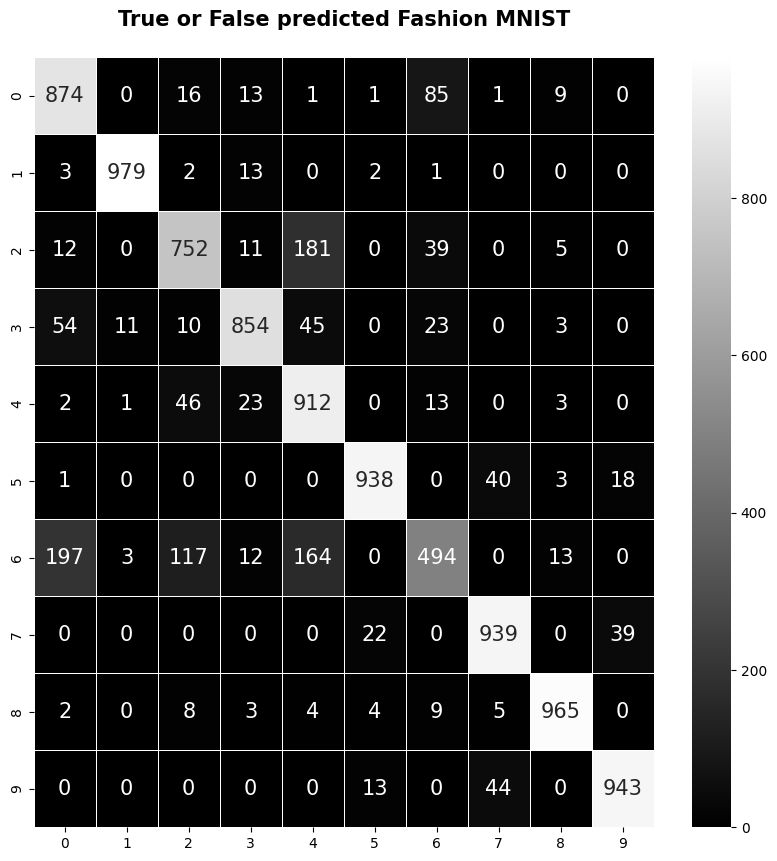

In [109]:
#check the metric using heatmap
con_mat=confusion_matrix(y_test_fashion_eval,y_pred_fashion)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size': 15},linewidths=0.5,fmt="d",cmap="gray")
plt.title('True or False predicted Fashion MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [110]:
from sklearn.metrics import classification_report

print(classification_report(y_test_fashion_eval,y_pred_fashion))

              precision    recall  f1-score   support

           0       0.76      0.87      0.81      1000
           1       0.98      0.98      0.98      1000
           2       0.79      0.75      0.77      1000
           3       0.92      0.85      0.89      1000
           4       0.70      0.91      0.79      1000
           5       0.96      0.94      0.95      1000
           6       0.74      0.49      0.59      1000
           7       0.91      0.94      0.93      1000
           8       0.96      0.96      0.96      1000
           9       0.94      0.94      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



In [87]:
print(result.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


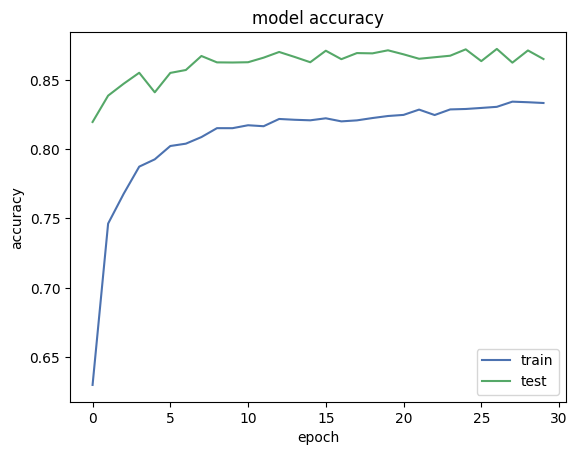

In [111]:
# summarize history for accuracy
plt.plot(result.history['accuracy'])
plt.plot(result.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

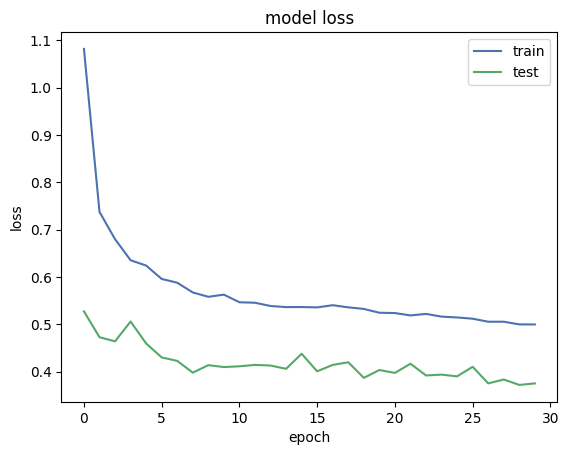

In [112]:
plt.plot(result.history['loss'])
plt.plot(result.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [113]:
y_predict = model.predict(x_test_fashion.loc[[0],:].values)
y_predict=np.argmax(y_predict, axis=1) # Here we get the index of maximum value in the encoded vector
y_test_digit_eval=np.argmax(y_test_fashion, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


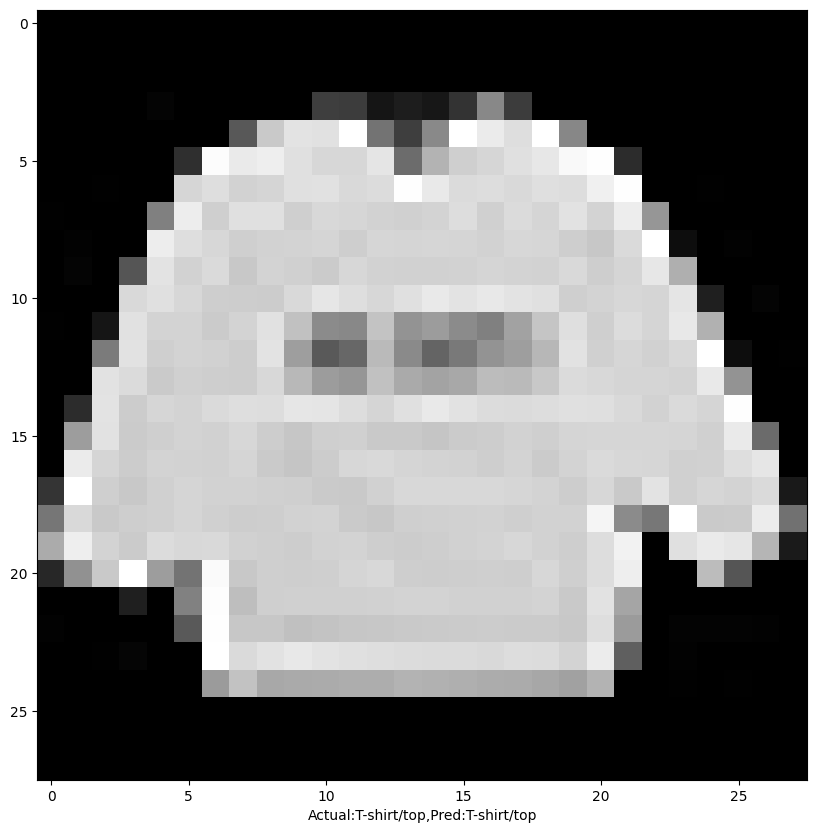

In [114]:
#Names of clothing accessories in order 
col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#Visualizing the images
plt.figure(figsize=(10,10))

plt.imshow(x_train_reshape[0], cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_fashion[0])],col_names[y_predict[0]]))
plt.show()